In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


# Finding the angles:
We have the length of the "tibia" and "femur", two parts of the robot. The tibia is the portion from the point contacting the floor to the first motor. The femur is the distance between both motors. The lengths are:

$$ L_{TIBIA} = 6 \text{ cm}$$
$$ L_{FEMUR} = 4 \text{ cm}$$

## Finding the coordinates of just the *tip*
In order to determine how the robot moves we concern ourselves with the robot's leg. Speficially, we want to focus on the tip of the leg making contact with the floor; we will call this tip the **toe**. We can define the location of the toe using a three tuple coordinate system $(x, y, z)$.

Given the angles $\theta_1$ and $\theta_2$ of the servo motors, $M_1$ and $M_2$ respectively, we can find the location of a single leg's toe.

For $z$, we know the following:


<!-- ADD IMAGE -->

For $x$ and $y$ we then have the following:

<!--ADD IMAGE 2 -->

So we now we know how to find the coordinates of the toe given the lengths of the components of the leg and the angles.

$$ z = L_{TIBIA} \times (1 - \sin{\theta_1}) $$

$$ x = ??? $$

$$ y = ??? $$

We call these equations the **direct kinematic equations** of a manipulator. While the leg does not conjure the idea of typical manipulator (i.e. an arm), the two joints enabling the leg's motion make it a manipulator.

## The inverse kinematics
In reality, we don't want to start with the angles and find the toe coordinates, while technically possible to  search through angles in order to find a $(\theta_1, \theta_2)$ pair that cooresponded to the points we want tp move the toe to it would be too slow to be viable.

With the **inverse kinematic equations** we start with the points we want to move to and find the angles we need.

For example,

$$ z = L_{TIBIA} \times (1 - \sin{\theta_1}) \rightarrow \theta_1 = \arcsin(1 - \dfrac{z}{L_{TIBIA}})$$

$$ \theta_2 = ??? $$

This notebook will use the inverse kinematic equations simulate one leg's movement.


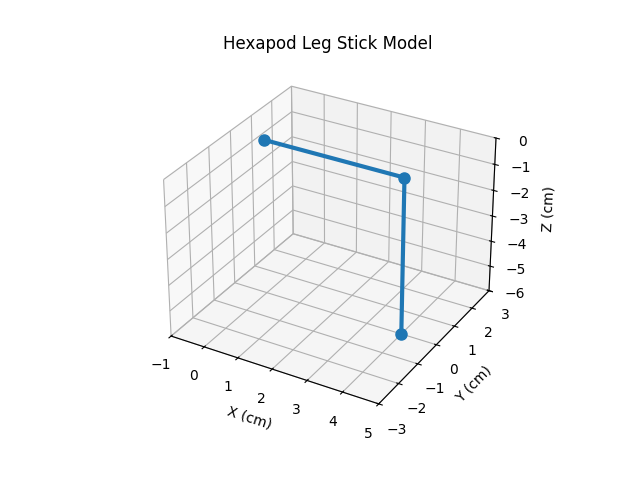

In [32]:
L_FEMUR = 4.0
L_TIBIA = 6.0

def calculate_ik(x, y, z, tolerance=1e-3):
    # 1. Calculate horizontal distance from hip
    r = np.sqrt(x**2 + y**2)
    r_remaining = r - L_FEMUR
    
    # 2. Reachability Check
    L_req = np.sqrt(r_remaining**2 + z**2)
    if abs(L_req - L_TIBIA) > tolerance:
        raise ValueError(f"Target ({x:.2f}, {y:.2f}, {z:.2f}) is out of reach.")

    # 3. Calculate mathematical angles
    theta1_math = np.degrees(np.atan2(y, x))
    theta2_math = np.degrees(np.atan2(z, r_remaining))
    
    # 4. Map to 0-180 Servos
    # Femur: Math 0 degrees (+X forward) maps to servo 90
    femur_servo = theta1_math + 90
    
    # Tibia: Math -90 degrees (straight down) maps to servo 90
    tibia_servo = theta2_math + 180
    
    return {
        "femur": max(0, min(180, femur_servo)),
        "tibia": max(0, min(180, tibia_servo))
    }


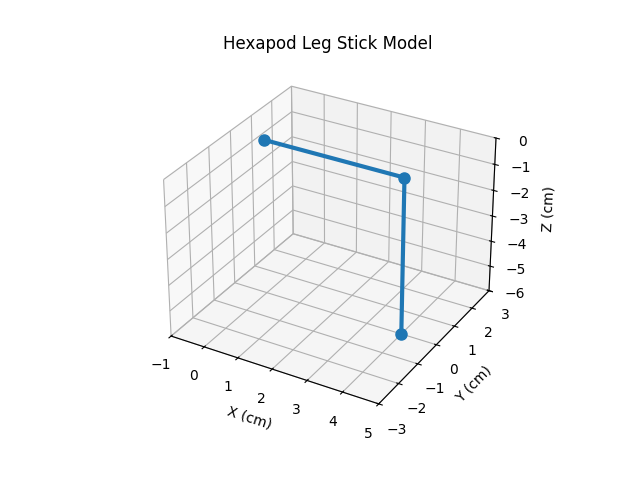

In [33]:

def plot_leg(angles):
    # Reverse servo mapping back to math radians for plotting
    t1 = np.radians(angles['femur'] - 90)
    t2 = np.radians(angles['tibia'] - 180) 

    # Joint 0: Origin (Hip mount)
    p0 = np.array([0, 0, 0])

    # Joint 1: End of Femur (Knee)
    p1 = np.array([L_FEMUR * np.cos(t1), L_FEMUR * np.sin(t1), 0])

    # Joint 2: End of Tibia (Foot tip)
    r_tibia_xy = L_TIBIA * np.cos(t2)
    p2 = p1 + np.array([r_tibia_xy * np.cos(t1), r_tibia_xy * np.sin(t1), L_TIBIA * np.sin(t2)])

    # Plotting
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    points = np.array([p0, p1, p2])
    
    ax.plot(points[:, 0], points[:, 1], points[:, 2], '-o', linewidth=3, markersize=8)
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')
    ax.set_zlabel('Z (cm)')
    ax.set_title('Hexapod Leg Stick Model')
    
    # Keep axes equal so the leg doesn't look stretched
    max_range = np.array([points[:,0].max()-points[:,0].min(), points[:,1].max()-points[:,1].min(), points[:,2].max()-points[:,2].min()]).max() / 2.0
    mid_x = (points[:,0].max()+points[:,0].min()) * 0.5
    mid_y = (points[:,1].max()+points[:,1].min()) * 0.5
    mid_z = (points[:,2].max()+points[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.show()

# Example test for resting position (straight down)
angles = calculate_ik(4, 0, -6)
plot_leg(angles)

In [40]:
%matplotlib inline
import time
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Setup the figure and axes once
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Set static plot boundaries so the axes don't jump around
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_zlim(-10, 2)
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_zlabel('Z (cm)')
ax.set_title('Single Hexapod Leg Sweep')

# Initialize an empty line object that we will update
line, = ax.plot([], [], [], '-o', linewidth=3, markersize=8)

# 2. Define the sweep trajectory parameters
sweep_angles_deg = np.linspace(-45, 45, 30)
radius = 4.0
z_height = -6.0

# 3. The update function called for each frame
def update(frame_angle):
    angle_rad = np.radians(frame_angle)
    target_x = radius * np.cos(angle_rad)
    target_y = radius * np.sin(angle_rad)
    target_z = z_height
    
    try:
        # Calculate joint angles using your existing IK function
        angles = calculate_ik(target_x, target_y, target_z)
        
        # Extract math angles
        t1 = np.radians(angles['femur'] - 90)
        t2 = np.radians(angles['tibia'] - 180) 
        
        # Calculate joint positions
        p0 = np.array([0, 0, 0])
        p1 = np.array([L_FEMUR * np.cos(t1), L_FEMUR * np.sin(t1), 0])
        
        r_tibia_xy = L_TIBIA * np.cos(t2)
        p2 = p1 + np.array([r_tibia_xy * np.cos(t1), r_tibia_xy * np.sin(t1), L_TIBIA * np.sin(t2)])
        
        points = np.array([p0, p1, p2])
        
        # Update the existing line's data rather than redrawing the figure
        line.set_data_3d(points[:, 0], points[:, 1], points[:, 2])
        
    except ValueError:
        pass # Skip unreachable coordinates
        
    return line,

anim = FuncAnimation(fig, update, frames=sweep_angles_deg, interval=100, blit=False)
plt.close() 
HTML(anim.to_jshtml())

In [ ]:
# Cell 1: Setup and "Hello World" Visualization
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Physical Constants (Adeept Pixie approximate lengths in mm)
L_COXA = 28.0
L_FEMUR = 45.0
L_TIBIA = 75.0

def get_leg_points(theta1_deg, theta2_deg, theta3_deg):
    """Calculates the (x,y,z) coordinates for each joint based on angles."""
    t1, t2, t3 = np.radians([theta1_deg, theta2_deg, theta3_deg + 90])

    # Joint 0: Hip Base
    p0 = np.array([0, 0, 0])
    
    # Joint 1: Hip Pivot
    p1 = np.array([L_COXA * np.cos(t1), L_COXA * np.sin(t1), 0])
    
    # Joint 2: Knee
    r_femur = L_FEMUR * np.cos(t2)
    p2 = p1 + np.array([r_femur * np.cos(t1), r_femur * np.sin(t1), L_FEMUR * np.sin(t2)])
    
    # Joint 3: Foot Tip
    r_tibia = L_TIBIA * np.cos(t2 - t3)
    p3 = p2 + np.array([r_tibia * np.cos(t1), r_tibia * np.sin(t1), L_TIBIA * np.sin(t2 - t3)])
    
    return np.array([p0, p1, p2, p3])

# Create the plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Generate points for a "Neutral" standing position
# Angles: Hip=0, Femur=45, Tibia=-45
points = get_leg_points(0, 45, -45)

# Draw the leg segments
ax.plot(points[:, 0], points[:, 1], points[:, 2], '-o', linewidth=4, markersize=10, color='blue')

# Formatting for clarity
ax.set_xlabel('X (Forward)')
ax.set_ylabel('Y (Side)')
ax.set_zlabel('Z (Height)')
ax.set_title('Adeept Hexapod: Single Leg Hello World')

# Fix the view limits so the leg doesn't look distorted
ax.set_xlim(-50, 150)
ax.set_ylim(-100, 100)
ax.set_zlim(-100, 100)

plt.show()

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Setup the figure for animation
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    ax.cla() # Clear the axis to redraw the limb
    
    # Define a simple "sweep" movement: X moves back and forth
    sweep_x = 100 + 30 * np.sin(np.radians(frame * 10))
    target_z = -60 + 20 * np.cos(np.radians(frame * 10))
    
    try:
        # Calculate IK and get points (using your existing functions)
        angles = calculate_ik(sweep_x, 0, target_z)
        points = get_leg_points(angles['coxa'], angles['femur'], angles['tibia'])
        
        # Draw the segments
        ax.plot(points[:, 0], points[:, 1], points[:, 2], '-o', linewidth=4, color='green')
        ax.scatter(sweep_x, 0, target_z, color='red', s=50) # Target tracker
        
    except ValueError:
        pass # Skip frames that are out of reach

    # Keep the view consistent
    ax.set_xlim(-50, 150); ax.set_ylim(-100, 100); ax.set_zlim(-100, 100)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    return ax,

# Create animation: 36 frames for a full 360-degree sine cycle
ani = FuncAnimation(fig, update, frames=36, interval=50)

# Display in the notebook
HTML(ani.to_jshtml()) 

# Save as a GIF
#ani.save('hexapod_step.gif', writer='pillow', fps=20)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

fig, ax = plt.subplots()

x = np.arange(0, 2*np.pi, 0.01)
line, = ax.plot(x, np.sin(x))


def animate(i):
    line.set_ydata(np.sin(x + i / 50))  # update the data.
    return line,


ani = animation.FuncAnimation(fig, animate, interval=20, blit=True, save_count=50)
plt.show()


In [ ]:
%matplotlib widget 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

t = np.linspace(0, 2*np.pi, 200)
x = np.cos(t)
y = np.sin(t)
z = 0.5*np.sin(2*t)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
line, = ax.plot([], [], [], lw=2)

def update(frame):
    line.set_data(x[:frame], y[:frame])
    line.set_3d_properties(z[:frame])
    return (line,)

anim = FuncAnimation(fig, update, frames=len(t), interval=30)  # ← MUST persist
plt.show()
